In [1]:
import freetype

font_file = "../fonts/字悦九叠印篆.ttf"
face = freetype.Face(font_file)
face.load_char("爽", freetype.FT_LOAD_NO_SCALE | freetype.FT_LOAD_NO_HINTING)

outline = face.glyph.outline

(<Figure size 800x800 with 1 Axes>, <Axes: >)

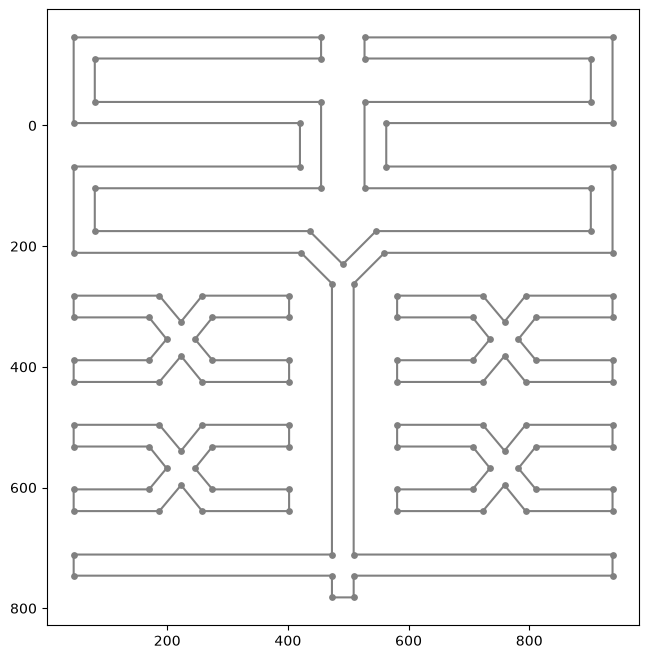

In [40]:
import matplotlib.pyplot as plt

points = outline.points
contours = outline.contours


def draw(points, contours, color=None, label_points=False, figure=None):
    if figure is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    else:
        fig, ax = figure

    start = 0

    for end in contours:
        contour = points[start : end + 1]

        x = [p[0] for p in contour]
        y = [p[1] for p in contour]

        # 闭合
        x.append(contour[0][0])
        y.append(contour[0][1])

        ax.plot(x, y, "-", color=color)
        ax.scatter(x[:-1], y[:-1], s=15, color=color)

        # 标注点编号（可选）
        if label_points:
            for idx, p in enumerate(contour, start):
                ax.text(p[0], p[1], str(idx), fontsize=8)

        start = end + 1

    ax.set_aspect("equal")
    ax.invert_yaxis()
    return fig, ax


draw(points, contours, color="gray")

In [5]:
def compute_edges(points, contours):
    edges = {}

    start = 0

    for end in contours:
        # 当前轮廓的所有点索引
        indices = list(range(start, end + 1))

        # 相邻点
        for i in range(len(indices)):
            idx1 = indices[i]
            idx2 = indices[(i + 1) % len(indices)]  # 最后一个自动连回第一个

            x1, y1 = points[idx1]
            x2, y2 = points[idx2]

            edges[(idx1, idx2)] = ((x2 - x1), (y2 - y1))

        start = end + 1
    return edges


edges = compute_edges(points, contours)
print(edges)

{(0, 1): (375, 0), (1, 2): (0, 72), (2, 3): (-375, 0), (3, 4): (0, 143), (4, 5): (377, 0), (5, 6): (51, 51), (6, 7): (0, 449), (7, 8): (-428, 0), (8, 9): (0, 35), (9, 10): (428, 0), (10, 11): (0, 36), (11, 12): (36, 0), (12, 13): (0, -36), (13, 14): (429, 0), (14, 15): (0, -35), (15, 16): (-429, 0), (16, 17): (0, -449), (17, 18): (51, -51), (18, 19): (378, 0), (19, 20): (0, -143), (20, 21): (-375, 0), (21, 22): (0, -72), (22, 23): (375, 0), (23, 24): (0, -142), (24, 25): (-411, 0), (25, 26): (0, 35), (26, 27): (375, 0), (27, 28): (0, 72), (28, 29): (-375, 0), (29, 30): (0, 143), (30, 31): (375, 0), (31, 32): (0, 71), (32, 33): (-356, 0), (33, 34): (-55, 55), (34, 35): (-55, -55), (35, 36): (-356, 0), (36, 37): (0, -71), (37, 38): (375, 0), (38, 39): (0, -143), (39, 40): (-375, 0), (40, 41): (0, -72), (41, 42): (375, 0), (42, 43): (0, -35), (43, 44): (-410, 0), (44, 0): (0, 142), (45, 46): (125, 0), (46, 47): (29, 36), (47, 48): (-29, 35), (48, 49): (-125, 0), (49, 50): (0, 36), (50, 51

In [6]:
import numpy as np

In [7]:
def smod(x, n):
    return ((x + n / 2) % n) - n / 2

In [8]:
def compute_gcd(edges):
    ds = []
    for dx, dy in edges.values():
        ds.extend([dx, dy])
    ds = np.asarray(ds)
    v_s, n_s = np.unique(ds[ds != 0], return_counts=True)
    gcd_candidate = v_s[n_s.argmax()]
    gcds = np.arange(gcd_candidate // 2 - 5, gcd_candidate // 2 + 5 + 1)
    loss = np.zeros_like(gcds)
    for i, d in enumerate(gcds):
        loss[i] = np.sum(np.abs(smod(v_s, d)) * n_s)
    gcd = gcds[loss.argmin()].item()
    return gcd, v_s, n_s, loss

In [9]:
gcd, v_s, n_s, loss = compute_gcd(edges)

In [13]:
gcd, _, _, _ = compute_gcd(edges)

In [14]:
def sdivide(x, n):
    k = round(x / n)
    return k * n

In [15]:
gcd = 18

In [16]:
# calibrate edges
calibrated_edges = {}
for pair, edge in edges.items():
    dx, dy = edge
    calibrated_edges[pair] = (sdivide(dx, gcd), sdivide(dy, gcd))

In [17]:
edges

{(0, 1): (375, 0),
 (1, 2): (0, 72),
 (2, 3): (-375, 0),
 (3, 4): (0, 143),
 (4, 5): (377, 0),
 (5, 6): (51, 51),
 (6, 7): (0, 449),
 (7, 8): (-428, 0),
 (8, 9): (0, 35),
 (9, 10): (428, 0),
 (10, 11): (0, 36),
 (11, 12): (36, 0),
 (12, 13): (0, -36),
 (13, 14): (429, 0),
 (14, 15): (0, -35),
 (15, 16): (-429, 0),
 (16, 17): (0, -449),
 (17, 18): (51, -51),
 (18, 19): (378, 0),
 (19, 20): (0, -143),
 (20, 21): (-375, 0),
 (21, 22): (0, -72),
 (22, 23): (375, 0),
 (23, 24): (0, -142),
 (24, 25): (-411, 0),
 (25, 26): (0, 35),
 (26, 27): (375, 0),
 (27, 28): (0, 72),
 (28, 29): (-375, 0),
 (29, 30): (0, 143),
 (30, 31): (375, 0),
 (31, 32): (0, 71),
 (32, 33): (-356, 0),
 (33, 34): (-55, 55),
 (34, 35): (-55, -55),
 (35, 36): (-356, 0),
 (36, 37): (0, -71),
 (37, 38): (375, 0),
 (38, 39): (0, -143),
 (39, 40): (-375, 0),
 (40, 41): (0, -72),
 (41, 42): (375, 0),
 (42, 43): (0, -35),
 (43, 44): (-410, 0),
 (44, 0): (0, 142),
 (45, 46): (125, 0),
 (46, 47): (29, 36),
 (47, 48): (-29, 35),


In [18]:
for pair, edge in edges.items():
    print(pair, edge, calibrated_edges[pair])

(0, 1) (375, 0) (378, 0)
(1, 2) (0, 72) (0, 72)
(2, 3) (-375, 0) (-378, 0)
(3, 4) (0, 143) (0, 144)
(4, 5) (377, 0) (378, 0)
(5, 6) (51, 51) (54, 54)
(6, 7) (0, 449) (0, 450)
(7, 8) (-428, 0) (-432, 0)
(8, 9) (0, 35) (0, 36)
(9, 10) (428, 0) (432, 0)
(10, 11) (0, 36) (0, 36)
(11, 12) (36, 0) (36, 0)
(12, 13) (0, -36) (0, -36)
(13, 14) (429, 0) (432, 0)
(14, 15) (0, -35) (0, -36)
(15, 16) (-429, 0) (-432, 0)
(16, 17) (0, -449) (0, -450)
(17, 18) (51, -51) (54, -54)
(18, 19) (378, 0) (378, 0)
(19, 20) (0, -143) (0, -144)
(20, 21) (-375, 0) (-378, 0)
(21, 22) (0, -72) (0, -72)
(22, 23) (375, 0) (378, 0)
(23, 24) (0, -142) (0, -144)
(24, 25) (-411, 0) (-414, 0)
(25, 26) (0, 35) (0, 36)
(26, 27) (375, 0) (378, 0)
(27, 28) (0, 72) (0, 72)
(28, 29) (-375, 0) (-378, 0)
(29, 30) (0, 143) (0, 144)
(30, 31) (375, 0) (378, 0)
(31, 32) (0, 71) (0, 72)
(32, 33) (-356, 0) (-360, 0)
(33, 34) (-55, 55) (-54, 54)
(34, 35) (-55, -55) (-54, -54)
(35, 36) (-356, 0) (-360, 0)
(36, 37) (0, -71) (0, -72)
(37,

In [19]:
# coordinate calibration
offset = points[0]
calibrated_points = [(0, 0)]
is_start_of_contour = False
for pair, edge in calibrated_edges.items():
    i, j = pair
    if is_start_of_contour:
        x, y = points[i]
        x_ = sdivide(x - offset[0], gcd)
        y_ = sdivide(y - offset[1], gcd)
        calibrated_points.append((x_, y_))
        is_start_of_contour = False
    if i < j:
        x, y = calibrated_points[i]
        dx, dy = edge
        calibrated_points.append((x + dx, y + dy))
    else:
        is_start_of_contour = True

In [20]:
calibrated_points

[(0, 0),
 (378, 0),
 (378, 72),
 (0, 72),
 (0, 216),
 (378, 216),
 (432, 270),
 (432, 720),
 (0, 720),
 (0, 756),
 (432, 756),
 (432, 792),
 (468, 792),
 (468, 756),
 (900, 756),
 (900, 720),
 (468, 720),
 (468, 270),
 (522, 216),
 (900, 216),
 (900, 72),
 (522, 72),
 (522, 0),
 (900, 0),
 (900, -144),
 (486, -144),
 (486, -108),
 (864, -108),
 (864, -36),
 (486, -36),
 (486, 108),
 (864, 108),
 (864, 180),
 (504, 180),
 (450, 234),
 (396, 180),
 (36, 180),
 (36, 108),
 (414, 108),
 (414, -36),
 (36, -36),
 (36, -108),
 (414, -108),
 (414, -144),
 (0, -144),
 (0, 324),
 (126, 324),
 (162, 360),
 (126, 396),
 (0, 396),
 (0, 432),
 (144, 432),
 (180, 396),
 (216, 432),
 (360, 432),
 (360, 396),
 (234, 396),
 (198, 360),
 (234, 324),
 (360, 324),
 (360, 288),
 (216, 288),
 (180, 324),
 (144, 288),
 (0, 288),
 (0, 540),
 (126, 540),
 (162, 576),
 (126, 612),
 (0, 612),
 (0, 648),
 (144, 648),
 (180, 612),
 (216, 648),
 (360, 648),
 (360, 612),
 (234, 612),
 (198, 576),
 (234, 540),
 (360, 

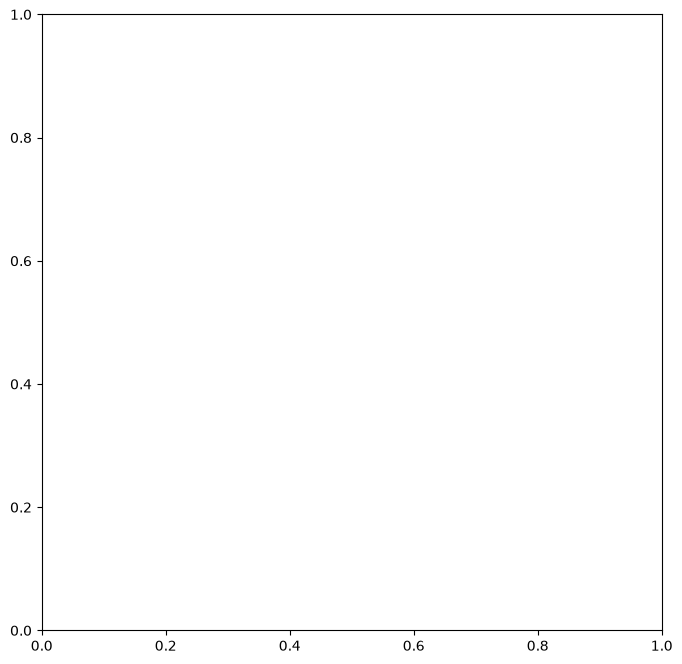

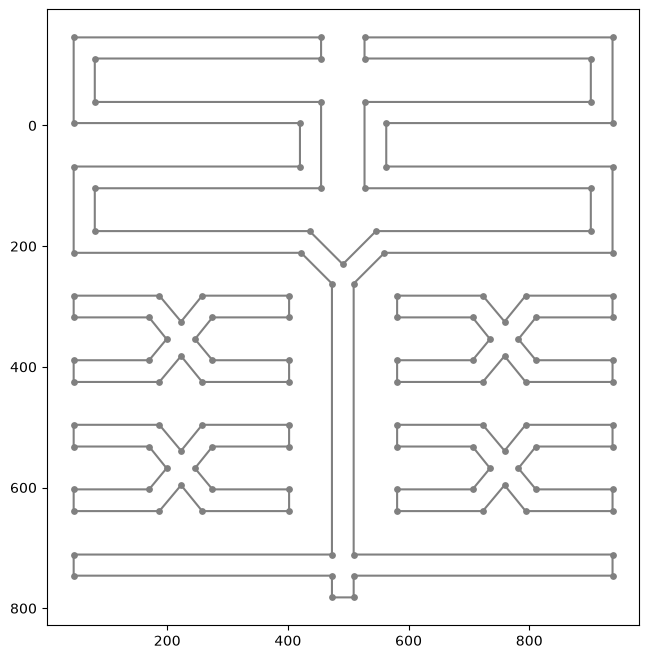

In [ ]:
figure = plt.subplots(figsize=(8, 8))

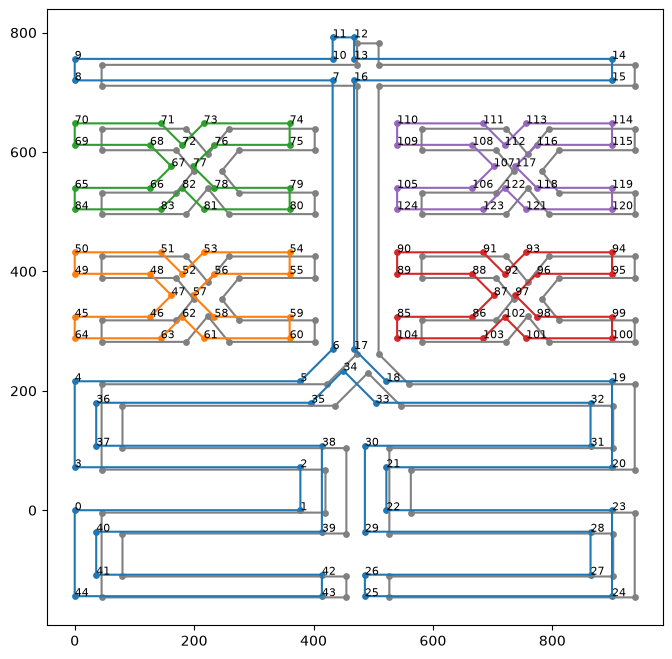

In [42]:
# 创建画布
fig, ax = plt.subplots(figsize=(8, 8))

# 多次调用 draw
draw(points, contours, color="gray", label_points=False, figure=(fig, ax))
draw(calibrated_points, contours, label_points=True, figure=(fig, ax))

# 最后显示
plt.show()

In [1]:
from calibrate import (
    compute_edges,
    compute_gcd_stage1,
    compute_gcd_stage2,
)

In [2]:
def compute_gcd_char(glyph):
    outline = glyph.outline
    points = outline.points
    contours = outline.contours

    edges = compute_edges(points, contours)
    gcd_candidate, v_s, n_s = compute_gcd_stage1(edges)
    gcd_candidate = gcd_candidate // 2  # 考虑公度量的一半，因为斜线笔画可能采用其一半
    # print(gcd_candidate)
    gcd, loss = compute_gcd_stage2(gcd_candidate, v_s, n_s)
    return gcd

In [3]:
import freetype
from utils import iter_glyph

font = "../fonts/字悦九叠印篆.ttf"
gcds = {}
face = freetype.Face(font)
for char in iter_glyph():
    face.load_char(char, freetype.FT_LOAD_NO_SCALE | freetype.FT_LOAD_NO_HINTING)
    glyph = face.glyph
    if glyph is not None:
        gcd = compute_gcd_char(glyph)
        gcds[char] = gcd

In [4]:
len(gcds)

98144

In [5]:
gcds

{'一': 36,
 '丁': 161,
 '丂': 159,
 '七': 53,
 '丄': 214,
 '丅': 214,
 '丆': 159,
 '万': 156,
 '丈': 18,
 '三': 429,
 '上': 380,
 '下': 214,
 '丌': 188,
 '不': 161,
 '与': 429,
 '丏': 159,
 '丐': 18,
 '丑': 214,
 '丒': 159,
 '专': 36,
 '且': 34,
 '丕': 75,
 '世': 156,
 '丗': 54,
 '丘': 187,
 '丙': 187,
 '业': 36,
 '丛': 18,
 '东': 36,
 '丝': 37,
 '丞': 49,
 '丟': 38,
 '丠': 159,
 '両': 102,
 '丢': 38,
 '丣': 159,
 '两': 161,
 '严': 18,
 '並': 134,
 '丧': 18,
 '丨': 107,
 '丩': 159,
 '个': 161,
 '丫': 210,
 '丬': 375,
 '中': 36,
 '丮': 159,
 '丯': 159,
 '丰': 53,
 '丱': 67,
 '串': 36,
 '丳': 159,
 '临': 36,
 '丵': 159,
 '丶': 69,
 '丷': 159,
 '丸': 321,
 '丹': 188,
 '为': 34,
 '主': 160,
 '丼': 159,
 '丽': 18,
 '举': 18,
 '丿': 161,
 '乀': 159,
 '乁': 159,
 '乂': 188,
 '乃': 375,
 '乄': 159,
 '久': 375,
 '乆': 159,
 '乇': 53,
 '么': 18,
 '义': 18,
 '乊': 159,
 '之': 161,
 '乌': 12,
 '乍': 321,
 '乎': 214,
 '乏': 166,
 '乐': 54,
 '乑': 159,
 '乒': 428,
 '乓': 428,
 '乔': 18,
 '乕': 159,
 '乖': 161,
 '乗': 159,
 '乘': 36,
 '乙': 67,
 '乚': 159,
 '乛': 159,
 '乜': 53,
 '九': 375,
 